In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
%pip install -U rdrobust


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
data = pd.read_csv("../HW3/data/output/final_star.csv")


/tmp/ipykernel_3026815/1166696413.py:1: DtypeWarning: Columns (100,101,102,103,104,105,106,107,108,111) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../HW3/data/output/final_star.csv")


In [3]:
print(list(data.columns))


['contractid', 'planid', 'fips', 'year', 'n_nonmiss', 'avg_enrollment', 'sd_enrollment', 'min_enrollment', 'max_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'eghp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'sd_eligibles', 'min_eligibles', 'max_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_reb', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'avg_ffscost', 'parta_enroll', 'partb_enroll', 'metric_01', 'metric_02', 'metric_03', 'metric_04'

In [4]:
# Question 1: 

d1 = data.copy()

# choose and clean variables
d1["star_rating"] = pd.to_numeric(d1["partcd_score"], errors="coerce")
d1["enrollment"] = pd.to_numeric(d1["avg_enrollment"], errors="coerce")
d1["market_share"] = np.where(
    pd.to_numeric(d1["avg_enrolled"], errors="coerce") > 0,
    d1["enrollment"] / pd.to_numeric(d1["avg_enrolled"], errors="coerce"),
    np.nan
)

# create table
summary = (
    d1.loc[d1["year"].between(2010, 2015)]
      .groupby("year")
      .agg(
          mean_star_rating=("star_rating", "mean"),
          mean_enrollments=("enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          n_plans=("planid", "count"),
      )
      .reset_index()
      .sort_values("year")
)

summary

,year,mean_star_rating,mean_enrollments,mean_market_share,n_plans
0,2010,2.969662,256.353663,0.064564,108222
1,2011,3.165988,343.358734,0.085547,68003
2,2012,3.352218,377.336484,0.085568,67254
3,2013,3.559948,395.516174,0.081451,68117
4,2014,3.824169,436.637121,0.079989,62344
5,2015,3.977247,469.679258,0.078689,65507


In [5]:
# Question 2

no_star_summary = (
    data.loc[data["year"].between(2010, 2015)]
        .assign(
            star_rating=lambda d: pd.to_numeric(d["partcd_score"], errors="coerce"),
            enrollment=lambda d: pd.to_numeric(d["avg_enrollment"], errors="coerce"),
            market_share=lambda d: np.where(
                pd.to_numeric(d["avg_enrolled"], errors="coerce") > 0,
                pd.to_numeric(d["avg_enrollment"], errors="coerce") / pd.to_numeric(d["avg_enrolled"], errors="coerce"),
                np.nan
            ),
        )
        .loc[lambda d: d["star_rating"].isna()]  # plans without a star rating
        .groupby("year")
        .agg(
            mean_enrollments=("enrollment", "mean"),
            mean_market_share=("market_share", "mean"),
            n_plans_no_star=("planid", "count"),
        )
        .reset_index()
        .sort_values("year")
)

no_star_summary

,year,mean_enrollments,mean_market_share,n_plans_no_star
0,2010,107.336869,0.066018,48643
1,2011,172.482650,0.087729,17195
2,2012,172.734040,0.056712,9077
3,2013,213.504441,0.060017,3661
4,2014,257.596264,0.055713,3708
5,2015,328.243183,0.051313,5338


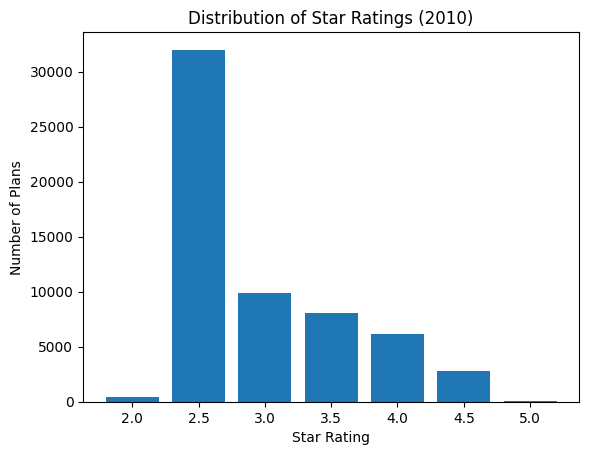

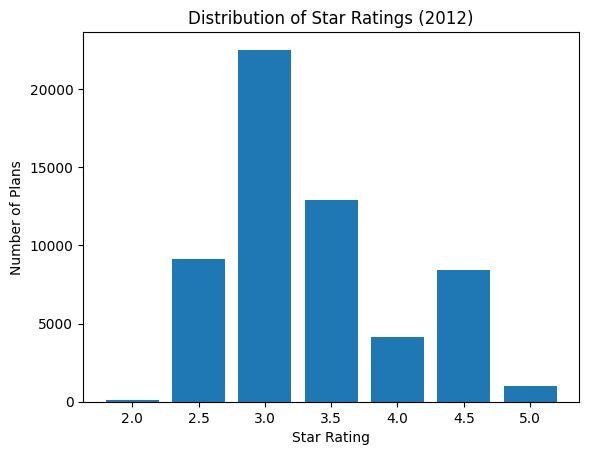

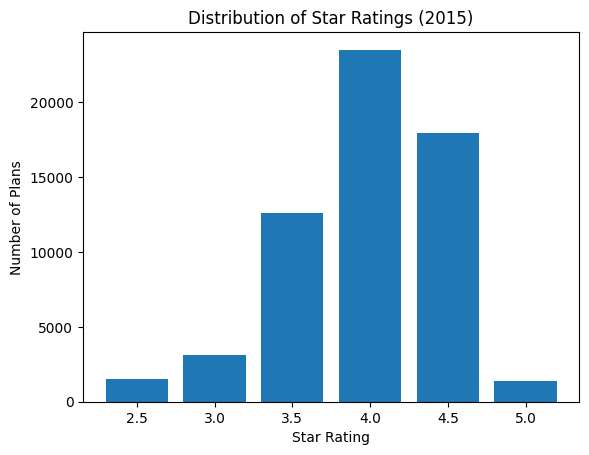

In [6]:
# question 3

# Clean star ratings (numeric)
df = data.copy()
df["star_rating"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Only rated plans and target years
years = [2010, 2012, 2015]
df = df[df["year"].isin(years) & df["star_rating"].notna()]


for y in years:
    sub = df[df["year"] == y]

    counts = (
        sub["star_rating"]
        .value_counts()
        .sort_index()
    )

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of Star Ratings ({y})")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of Plans")
    plt.show()

In [7]:
# Question 4
d4 = data.copy()

# Dependent variable: market share (plan enrollment / total enrolled in county)
d4["market_share"] = np.where(
    pd.to_numeric(d4["avg_enrolled"], errors="coerce") > 0,
    pd.to_numeric(d4["avg_enrollment"], errors="coerce") / pd.to_numeric(d4["avg_enrolled"], errors="coerce"),
    np.nan
)

# Star rating
d4["star"] = pd.to_numeric(d4["partcd_score"], errors="coerce")

# Star bucket indicators (excluded category: star <= 2.5)
d4["star_3"]   = ((d4["star"] > 2.5) & (d4["star"] < 3.5)).astype(int)    # 3.0
d4["star_35"]  = ((d4["star"] >= 3.5) & (d4["star"] < 4.0)).astype(int)   # 3.5
d4["star_4"]   = ((d4["star"] >= 4.0) & (d4["star"] < 4.5)).astype(int)   # 4.0
d4["star_45p"] = (d4["star"] >= 4.5).astype(int)                          # 4.5+

years = range(2010, 2016)
rows = ["Intercept", "Star = 3.0", "Star = 3.5", "Star = 4.0", "Star >= 4.5", "N"]

coef_table = pd.DataFrame(index=rows, columns=[str(y) for y in years], dtype=object)

for yr in years:
    sub = (
        d4.loc[d4["year"] == yr, ["market_share", "star_3", "star_35", "star_4", "star_45p"]]
        .dropna(subset=["market_share"])
        .copy()
    )

    # OLS for each year (intercept included by default)
    model = smf.ols("market_share ~ star_3 + star_35 + star_4 + star_45p", data=sub).fit()
    
   # Fill table with coef (se)
    coef_table.loc["Intercept", str(yr)]     = f"{model.params.get('Intercept', np.nan):.4f} ({model.bse.get('Intercept', np.nan):.4f})"
    coef_table.loc["Star = 3.0", str(yr)]    = f"{model.params.get('star_3', np.nan):.4f} ({model.bse.get('star_3', np.nan):.4f})"
    coef_table.loc["Star = 3.5", str(yr)]    = f"{model.params.get('star_35', np.nan):.4f} ({model.bse.get('star_35', np.nan):.4f})"
    coef_table.loc["Star = 4.0", str(yr)]    = f"{model.params.get('star_4', np.nan):.4f} ({model.bse.get('star_4', np.nan):.4f})"
    coef_table.loc["Star >= 4.5", str(yr)]   = f"{model.params.get('star_45p', np.nan):.4f} ({model.bse.get('star_45p', np.nan):.4f})"
    coef_table.loc["N", str(yr)]             = int(model.nobs)

coef_table

,2010,2011,2012,2013,2014,2015
Intercept,0.0644 (0.0007),0.0804 (0.0012),0.0661 (0.0017),0.0532 (0.0020),0.0614 (0.0026),0.0540 (0.0021)
Star = 3.0,0.0102 (0.0018),0.0236 (0.0019),0.0417 (0.0021),0.0602 (0.0027),0.0229 (0.0034),0.0374 (0.0035)
Star = 3.5,-0.0014 (0.0019),0.0084 (0.0024),0.0251 (0.0025),0.0339 (0.0023),0.0328 (0.0029),0.0503 (0.0027)
Star = 4.0,-0.0055 (0.0021),-0.0094 (0.0036),-0.0082 (0.0035),0.0189 (0.0032),0.0104 (0.0032),0.0166 (0.0024)
Star >= 4.5,-0.0093 (0.0028),-0.0215 (0.0029),-0.0001 (0.0027),0.0148 (0.0027),0.0072 (0.0031),0.0278 (0.0025)
N,30545,24194,24297,25219,24636,24852


In [8]:
# Question 5 (with exclusion of plans already exactly at rounded star)

d5 = data.loc[data["year"] == 2010].copy()

d5["star"] = pd.to_numeric(d5["partcd_score"], errors="coerce")

metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]
missing_metrics = [c for c in metric_cols if c not in d5.columns]
if missing_metrics:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d5[c] = pd.to_numeric(d5[c], errors="coerce")

d5["running"] = d5[metric_cols].mean(axis=1, skipna=True)
d5.loc[d5[metric_cols].notna().sum(axis=1) < 20, "running"] = np.nan

bins   = [2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
labels = ["3.0", "3.5", "4.0", "4.5", "5.0"]

d5["rounded_up_to"] = pd.cut(d5["running"], bins=bins, right=False, labels=labels)
d5["rounded_up_to_num"] = pd.to_numeric(d5["rounded_up_to"].astype(str), errors="coerce")


eps = 1e-8
d5["already_exact_at_star"] = (
    d5["running"].notna() &
    d5["star"].notna() &
    (np.abs(d5["running"] - d5["star"]) < eps) &
    (d5["star"].isin([3.0, 3.5, 4.0, 4.5, 5.0]))
)

# Keep only aligned rows AND not "already exact"
d5_aligned = d5.loc[
    d5["rounded_up_to"].notna() &
    d5["star"].notna() &
    d5["rounded_up_to_num"].notna() &
    (d5["star"] == d5["rounded_up_to_num"]) &
    (~d5["already_exact_at_star"])
].copy()

rounded_counts = (
    d5_aligned
      .groupby("rounded_up_to")
      .size()
      .reindex(labels, fill_value=0)
      .reset_index(name="n_plans")
      .rename(columns={"rounded_up_to": "rounded_up_star"})
)

rounded_counts

/tmp/ipykernel_3026815/390385939.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rounded_up_to")


,rounded_up_star,n_plans
0,3.0,8178
1,3.5,7428
2,4.0,3601
3,4.5,44
4,5.0,30


In [9]:
# Question 6 (RD treatment effects on MARKET SHARE, bandwidth h = 0.125)

import numpy as np
import pandas as pd
import statsmodels.api as sm

d6 = data.loc[data["year"] == 2010].copy()

# --- Build market share outcome (decimal) ---
# market_share = plan enrollment / total enrolled in county (or relevant market total)
d6["avg_enrollment"] = pd.to_numeric(d6["avg_enrollment"], errors="coerce")
d6["avg_enrolled"] = pd.to_numeric(d6["avg_enrolled"], errors="coerce")

d6["market_share"] = np.where(
    d6["avg_enrolled"] > 0,
    d6["avg_enrollment"] / d6["avg_enrolled"],
    np.nan
)

outcome_col = "market_share"

# --- Running variable from underlying metrics ---
metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]
missing_metrics = [c for c in metric_cols if c not in d6.columns]
if missing_metrics:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d6[c] = pd.to_numeric(d6[c], errors="coerce")

d6["running"] = d6[metric_cols].mean(axis=1, skipna=True)

# Enforce minimum non-missing metrics for reliability
min_metrics = 20
d6.loc[d6[metric_cols].notna().sum(axis=1) < min_metrics, "running"] = np.nan

def rd_local_linear_fit(df, outcome, running, cutoff, h):
    """
    Local linear RD within [cutoff-h, cutoff+h]:
      y = a + tau*Rounded + b*Score + c*(Rounded*Score) + e
    where Score = running - cutoff and Rounded = 1[running >= cutoff].
    tau is the RD treatment effect (jump at the cutoff).
    """
    d = df[[outcome, running]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()
    if d.empty:
        return None

    d["Rounded"] = (d[running] >= cutoff).astype(int)
    d["Score"] = d[running] - cutoff
    d["Rounded_x_Score"] = d["Rounded"] * d["Score"]

    X = sm.add_constant(d[["Rounded", "Score", "Rounded_x_Score"]])
    y = d[outcome]

    m = sm.OLS(y, X).fit(cov_type="HC1")
    return m


# --- Run RD at the two star thresholds (bandwidth required by prompt) ---
h = 0.125
m_30 = rd_local_linear_fit(d6, outcome_col, "running", cutoff=2.75, h=h)
m_35 = rd_local_linear_fit(d6, outcome_col, "running", cutoff=3.25, h=h)

if (m_30 is None) or (m_35 is None):
    raise ValueError(
        "No observations in one of the RD windows with h=0.125. "
        "This usually means your running variable isn't on the expected scale near 2.75/3.25 "
        "or min_metrics is filtering too aggressively."
    )

    # --- Regression-style table output (like the example) ---
row_keys = [
    ("(Intercept)", "const"),
    ("Rounded", "Rounded"),
    ("Running Score", "Score"),
    ("Rounded x Score", "Rounded_x_Score"),
]

index = []
for name, _ in row_keys:
    index += [name, ""]  # second line for SE

table = pd.DataFrame(index=index + ["Num.Obs.", "R2"], columns=["3 Stars", "3.5 Stars"])

def fill_col(m, col, digits=3):
    r = 0
    for name, key in row_keys:
        table.iloc[r, table.columns.get_loc(col)] = f"{m.params[key]:.{digits}f}"
        table.iloc[r+1, table.columns.get_loc(col)] = f"({m.bse[key]:.{digits}f})"
        r += 2
    table.loc["Num.Obs.", col] = int(m.nobs)
    table.loc["R2", col] = f"{m.rsquared:.3f}"

fill_col(m_30, "3 Stars", digits=3)
fill_col(m_35, "3.5 Stars", digits=3)

table

,3 Stars,3.5 Stars
(Intercept),0.035,0.100
,(0.003),(0.009)
Rounded,0.014,-0.050
,(0.009),(0.010)
Running Score,-0.589,0.201
,(0.043),(0.095)
Rounded x Score,1.018,-0.023
,(0.123),(0.127)
Num.Obs.,5297,1924
R2,0.035,0.017


/tmp/ipykernel_3026815/4082766433.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


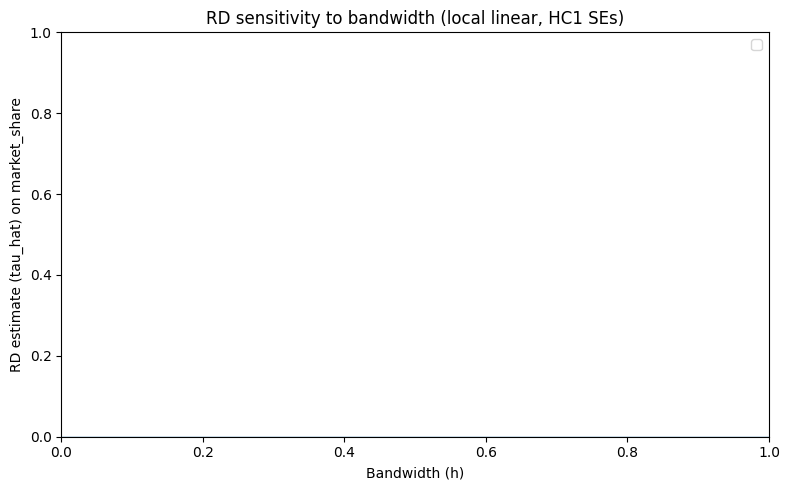

In [10]:
# Question 7 (MARKET SHARE): RD sensitivity across bandwidths + graph (3-star and 3.5-star cutoffs)

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

d7 = data.loc[data["year"] == 2010].copy()

# Published star for reference (optional)
d7["star"] = pd.to_numeric(d7["partcd_score"], errors="coerce")

# ---- Outcome: market share (decimal) ----
d7["avg_enrollment"] = pd.to_numeric(d7["avg_enrollment"], errors="coerce")
d7["avg_enrolled"] = pd.to_numeric(d7["avg_enrolled"], errors="coerce")

d7["market_share"] = np.where(
    d7["avg_enrolled"] > 0,
    d7["avg_enrollment"] / d7["avg_enrolled"],
    np.nan
)

outcome_col = "market_share"

# ---- Running variable from underlying metrics ----
metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]
missing_metrics = [c for c in metric_cols if c not in d7.columns]
if missing_metrics:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d7[c] = pd.to_numeric(d7[c], errors="coerce")

d7["running"] = d7[metric_cols].mean(axis=1, skipna=True)

min_metrics = 20
d7.loc[d7[metric_cols].notna().sum(axis=1) < min_metrics, "running"] = np.nan

def rd_local_linear(df, outcome, running="running", cutoff=2.75, h=0.125, min_n=20):
    d = df[[outcome, running]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()

    if d.empty:
        return {
            "cutoff": cutoff, "bandwidth": h, "n": 0,
            "tau_hat": np.nan, "se_HC1": np.nan, "p_value": np.nan,
            "note": "No observations in window."
        }

    note = ""
    if d.shape[0] < min_n:
        note = f"Small n (n={d.shape[0]})."

    d["treat"] = (d[running] >= cutoff).astype(int)
    d["x"] = d[running] - cutoff
    d["treat_x"] = d["treat"] * d["x"]

    X = sm.add_constant(d[["treat", "x", "treat_x"]])
    y = d[outcome]

    m = sm.OLS(y, X).fit(cov_type="HC1")

    return {
        "cutoff": cutoff,
        "bandwidth": h,
        "n": int(m.nobs),
        "tau_hat": float(m.params["treat"]),
        "se_HC1": float(m.bse["treat"]),
        "p_value": float(m.pvalues["treat"]),
        "note": note
    }

# --- Sensitivity table across required bandwidths ---
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]

cutoffs = [
    (2.75, "3.0 vs 2.5 (cutoff 2.75)"),
    (3.25, "3.5 vs 3.0 (cutoff 3.25)")
]

rows = []
for h in bandwidths:
    for c, label in cutoffs:
        res = rd_local_linear(d7, outcome=outcome_col, cutoff=c, h=h)
        rows.append({"comparison": label, **res})

results7 = pd.DataFrame(rows)
results7["ci95_low"] = results7["tau_hat"] - 1.96 * results7["se_HC1"]
results7["ci95_high"] = results7["tau_hat"] + 1.96 * results7["se_HC1"]

results7_table = results7[[
    "comparison", "cutoff", "bandwidth", "n",
    "tau_hat", "se_HC1", "ci95_low", "ci95_high", "p_value", "note"
]].sort_values(["comparison", "bandwidth"])

results7_table


# --- Plot tau_hat vs bandwidth with 95% CI ---
plot_df = results7.dropna(subset=["tau_hat", "se_HC1", "bandwidth"]).copy()
plot_df = plot_df.loc[plot_df["se_HC1"] > 0].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for comp in plot_df["comparison"].unique():
    tmp = plot_df.loc[plot_df["comparison"] == comp].sort_values("bandwidth")
    if tmp.empty:
        continue

        ax.errorbar(
        tmp["bandwidth"].to_numpy(),
        tmp["tau_hat"].to_numpy(),
        yerr=(1.96 * tmp["se_HC1"]).to_numpy(),
        marker="o",
        linestyle="-",
        capsize=3,
        label=comp
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("Bandwidth (h)")
ax.set_ylabel("RD estimate (tau_hat) on market_share")
ax.set_title("RD sensitivity to bandwidth (local linear, HC1 SEs)")
ax.legend()
plt.tight_layout()
plt.show()


----------------------------------------------------------------------
Cutoff 2.75 (2.5 -> 3.0)


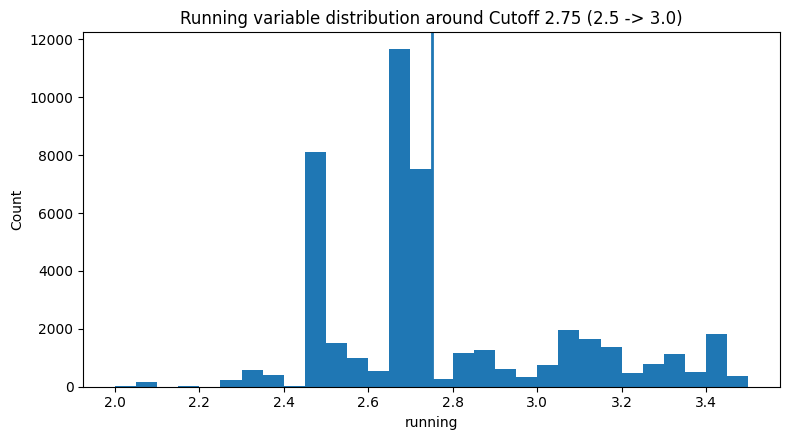

Total in window [2.00, 3.50]: n=46512
Close-left  [2.50, 2.75): n=22235
Close-right [2.75, 3.00]: n=4367

Top mass points (value counts) in the window:
running
2.4815    8006
2.7407    6827
2.6667    6435
2.6923    4874
3.3333     927
2.5172     859
2.8800     853
3.0000     684
3.0968     661
3.0625     631
Name: count, dtype: int64

----------------------------------------------------------------------
Cutoff 3.25 (3.0 -> 3.5)


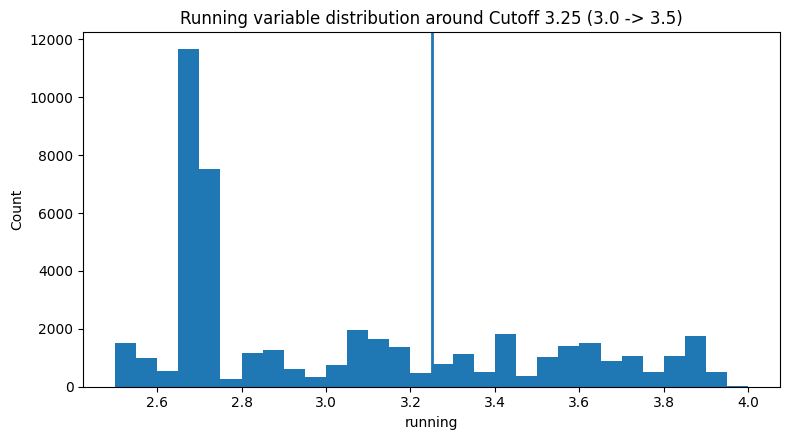

Total in window [2.50, 4.00]: n=46828
Close-left  [3.00, 3.25): n=6174
Close-right [3.25, 3.50]: n=4884

Top mass points (value counts) in the window:
running
2.7407    6827
2.6667    6435
2.6923    4874
3.8929    1072
3.3333     927
3.6071     904
2.5172     859
2.8800     853
3.5517     826
3.0000     684
Name: count, dtype: int64


In [11]:
# Question 8 

d8 = data.loc[data["year"] == 2010].copy()

metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]

missing_metrics = [c for c in metric_cols if c not in d8.columns]
if missing_metrics:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d8[c] = pd.to_numeric(d8[c], errors="coerce")

d8["running"] = d8[metric_cols].mean(axis=1, skipna=True)

min_metrics = 20
d8.loc[d8[metric_cols].notna().sum(axis=1) < min_metrics, "running"] = np.nan

cutoffs = [
    (2.75, "Cutoff 2.75 (2.5 -> 3.0)"),
    (3.25, "Cutoff 3.25 (3.0 -> 3.5)")
]

# Window half-width and bin width
w = 0.75
bin_width = 0.05  
close = 0.25

for c, label in cutoffs:
    x = d8["running"].dropna()
    xw = x.loc[(x >= c - w) & (x <= c + w)].copy()

    print("\n" + "-" * 70)
    print(label)

    if xw.empty:
        print(f"No observations in window [{c-w:.2f}, {c+w:.2f}].")
        continue

    bins = np.arange(c - w, c + w + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(xw.to_numpy(), bins=bins)
    ax.axvline(c, linewidth=2)
    ax.set_title(f"Running variable distribution around {label}")
    ax.set_xlabel("running")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    left_close = xw.loc[(xw >= c - close) & (xw < c)]
    right_close = xw.loc[(xw >= c) & (xw <= c + close)]

    print(f"Total in window [{c-w:.2f}, {c+w:.2f}]: n={len(xw)}")
    print(f"Close-left  [{c-close:.2f}, {c:.2f}): n={len(left_close)}")
    print(f"Close-right [{c:.2f}, {c+close:.2f}]: n={len(right_close)}")

    vc = xw.round(4).value_counts().sort_index()
    print("\nTop mass points (value counts) in the window:")
    print(vc.sort_values(ascending=False).head(10))


Love table: cutoff 2.75


,cutoff_label,cutoff,bandwidth,covariate,n,mean_below,mean_above,smd,abs_smd
0,Cutoff 2.75 (2.5 vs 3.0),2.75,0.125,HMO indicator,21265,0.037526,0.395174,0.964052,0.964052
1,Cutoff 2.75 (2.5 vs 3.0),2.75,0.125,Part D indicator,21265,0.524536,0.910456,0.948660,0.948660



Love table: cutoff 3.25


,cutoff_label,cutoff,bandwidth,covariate,n,mean_below,mean_above,smd,abs_smd
0,Cutoff 3.25 (3.0 vs 3.5),3.25,0.125,Part D indicator,5380,0.908344,0.844765,-0.194149,0.194149
1,Cutoff 3.25 (3.0 vs 3.5),3.25,0.125,HMO indicator,5380,0.482617,0.481498,-0.002239,0.002239


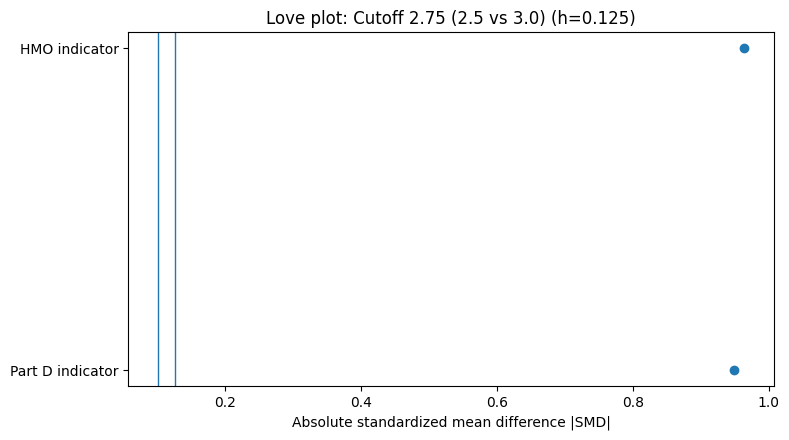

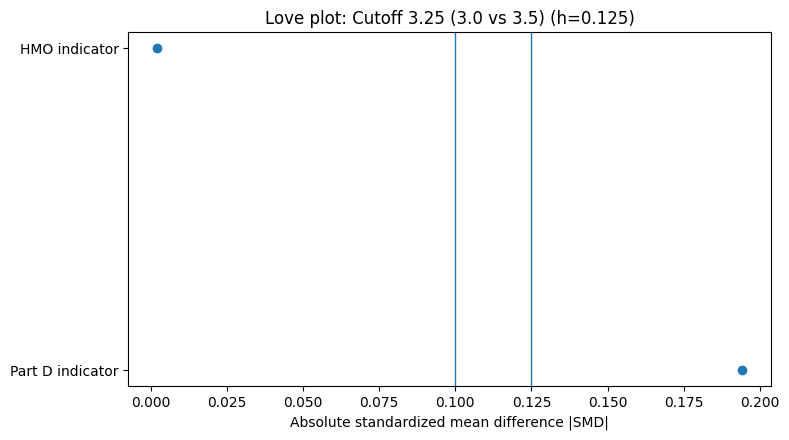

In [12]:
# Question 9 (fixed cell)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d9 = data.loc[data["year"] == 2010].copy()

# Running variable from underlying metrics
metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]
missing_metrics = [c for c in metric_cols if c not in d9.columns]
if missing_metrics:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d9[c] = pd.to_numeric(d9[c], errors="coerce")

d9["running"] = d9[metric_cols].mean(axis=1, skipna=True)

min_metrics = 20
d9.loc[d9[metric_cols].notna().sum(axis=1) < min_metrics, "running"] = np.nan

# Covariates
d9["hmo"] = d9["plan_type"].astype(str).str.upper().str.contains("HMO", na=False).astype(int)

partd_str = d9["partd"].astype(str).str.strip().str.upper()
d9["partd_bin"] = np.where(
    partd_str.isin(["1", "Y", "YES", "TRUE", "T"]),
    1,
    np.where(
        partd_str.isin(["0", "N", "NO", "FALSE", "F"]),
        0,
        pd.to_numeric(d9["partd"], errors="coerce")
    )
)

def smd_in_window(df, var, running="running", cutoff=2.75, h=0.125):
    d = df[[running, var]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()
    if d.empty:
        return {"n": 0, "mean_below": np.nan, "mean_above": np.nan, "smd": np.nan}

    d["above"] = (d[running] >= cutoff).astype(int)

    below = d.loc[d["above"] == 0, var].astype(float)
    above = d.loc[d["above"] == 1, var].astype(float)
    if below.empty or above.empty:
        return {"n": int(len(d)), "mean_below": np.nan, "mean_above": np.nan, "smd": np.nan}

    mean_below = float(below.mean())
    mean_above = float(above.mean())

    sd_below = float(below.std(ddof=1))
    sd_above = float(above.std(ddof=1))
    pooled = np.sqrt((sd_below**2 + sd_above**2) / 2)

    smd = (mean_above - mean_below) / pooled if pooled > 0 else np.nan
    return {"n": int(len(d)), "mean_below": mean_below, "mean_above": mean_above, "smd": float(smd)}

covars = {"hmo": "HMO indicator", "partd_bin": "Part D indicator"}

cutoffs = [
    (2.75, "Cutoff 2.75 (2.5 vs 3.0)"),
    (3.25, "Cutoff 3.25 (3.0 vs 3.5)")
]

h = 0.125

# Build love_df
rows = []
for c, c_label in cutoffs:
    for v, v_label in covars.items():
        out = smd_in_window(d9, var=v, cutoff=c, h=h)
        rows.append({
            "cutoff_label": c_label,
            "cutoff": c,
            "bandwidth": h,
            "covariate": v_label,
            "n": out["n"],
            "mean_below": out["mean_below"],
            "mean_above": out["mean_above"],
            "smd": out["smd"],
            "abs_smd": np.abs(out["smd"]) if pd.notna(out["smd"]) else np.nan
        })

love_df = pd.DataFrame(rows)

# Two tables
love_275 = love_df.loc[love_df["cutoff"] == 2.75].sort_values("abs_smd", ascending=False).reset_index(drop=True)
love_325 = love_df.loc[love_df["cutoff"] == 3.25].sort_values("abs_smd", ascending=False).reset_index(drop=True)

print("\nLove table: cutoff 2.75")
display(love_275)

print("\nLove table: cutoff 3.25")
display(love_325)

# Two separate love plots
plot_df = love_df.dropna(subset=["abs_smd"]).copy()

order = (
    plot_df.groupby("covariate")["abs_smd"]
    .max()
    .sort_values(ascending=True)
    .index
)

for c, c_label in cutoffs:
    tmp = plot_df.loc[plot_df["cutoff"] == c].copy()
    tmp["covariate"] = pd.Categorical(tmp["covariate"], categories=order, ordered=True)
    tmp = tmp.sort_values("covariate")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(tmp["abs_smd"].to_numpy(), tmp["covariate"].astype(str).to_numpy(),
            marker="o", linestyle="")

    ax.axvline(0.10, linewidth=1)
    ax.axvline(0.125, linewidth=1)

    ax.set_xlabel("Absolute standardized mean difference |SMD|")
    ax.set_ylabel("")
    ax.set_title(f"Love plot: {c_label} (h={h})")
    plt.tight_layout()
    plt.show()

In [13]:
# Question 10: Higher star ratings are associated with increased enrollment and larger market shares, but the evidence is not entirely robust as a movement from 2.5 to 3 seems to increase enrollment while a jump from 3 to 3.5 may not necessarily.
